<a href="https://colab.research.google.com/github/hollymunck-glitch/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

Business framing:  

Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Load the hotel bookings dataset by [downloading the file](https://github.com/rfordatascience/tidytuesday/blob/main/data/2020/2020-02-11/readme.md#get-the-data-here) or using this link: https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-02-11/hotels.csv
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [2]:
# Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-02-11/hotels.csv")

# Display the first few rows
display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### ✍️ Your Response: 🔧
1. From the first few rows of the dataset, it’s clear to see that the hotel bookings data has a mix of numerical and categorical variables describing each reservation. There are columns like hotel, is_canceled, lead_time, and adr that show booking behavior and price information, while others like meal, market_segment, and deposit_type show how and where the booking was made. Some things, like agent and company, have many missing or blank values, which will likely need to be cleaned before analysis. I also noticed several columns related to guest details, such as adults, children, and babies, which mostly have zeros in the first few rows.The data looks organized and detailed, but it will need some preprocessing to handle missing values and encode categorical variables before clustering.

## 2. Select and Prepare Features

Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [3]:
# Add code here 🔧
# Select and prepare features for clustering

from sklearn.preprocessing import StandardScaler

# Choose numeric features related to customer behavior
features = ['lead_time', 'stays_in_week_nights', 'stays_in_weekend_nights',
            'adr', 'total_of_special_requests']

# Drop missing values for the selected columns
df_features = df[features].dropna()

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

# Preview the standardized data
pd.DataFrame(X_scaled, columns=features).head()



,lead_time,stays_in_week_nights,stays_in_weekend_nights,adr,total_of_special_requests
0,2.227051,-1.310240,-0.92889,-2.015038,-0.720694
1,5.923385,-1.310240,-0.92889,-2.015038,-0.720694
2,-0.907814,-0.786207,-0.92889,-0.530935,-0.720694
3,-0.851667,-0.786207,-0.92889,-0.530935,-0.720694
4,-0.842309,-0.262174,-0.92889,-0.075810,0.540666


### ✍️ Your Response: 🔧
1. I chose lead_time, stays_in_week_nights, stays_in_weekend_nights, adr, and total_of_special_requests. These features show how early guests book, how long they stay, how much they pay per night, and how many extra requests they make. They give a good picture of guest behavior and spending patterns.

2. I expect to see groups like short-stay guests who book last minute, long-stay guests who plan early, and high-paying guests who make several special requests.


## 3. Apply K-Means Clustering

Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



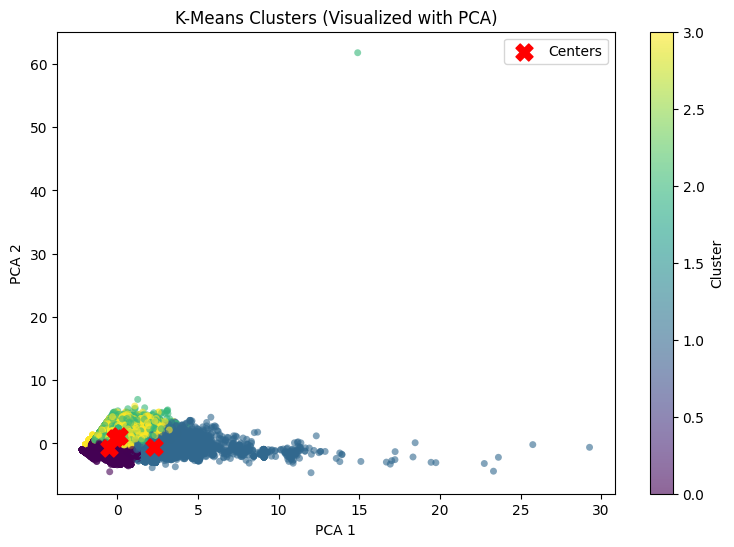

K-Means Cluster Summary:
         lead_time  stays_in_week_nights  stays_in_weekend_nights     adr  \
cluster                                                                     
0           126.67                  1.88                     0.62   82.26   
1           148.53                  5.93                     2.42   94.36   
2            63.17                  2.41                     0.93  183.00   
3            65.88                  2.05                     0.77   96.74   

         total_of_special_requests  
cluster                             
0                             0.05  
1                             0.57  
2                             0.55  
3                             1.49  


In [6]:
# --- Improved K-Means Visualization and Summary ---

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Fit KMeans (same as before)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)
df_features['cluster'] = kmeans.labels_

# PCA for 2D visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(9,6))
scatter = plt.scatter(pca_data[:,0], pca_data[:,1],
                      c=df_features['cluster'], cmap='viridis',
                      s=25, alpha=0.6, edgecolors='none')
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clusters (Visualized with PCA)')

# Plot cluster centers (converted to PCA space)
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:,0], centers_pca[:,1],
            c='red', s=150, marker='X', label='Centers')
plt.legend()
plt.show()

# Summarize average behavior per cluster
cluster_summary_kmeans = df_features.groupby('cluster')[features].mean().round(2)
print("K-Means Cluster Summary:")
print(cluster_summary_kmeans)


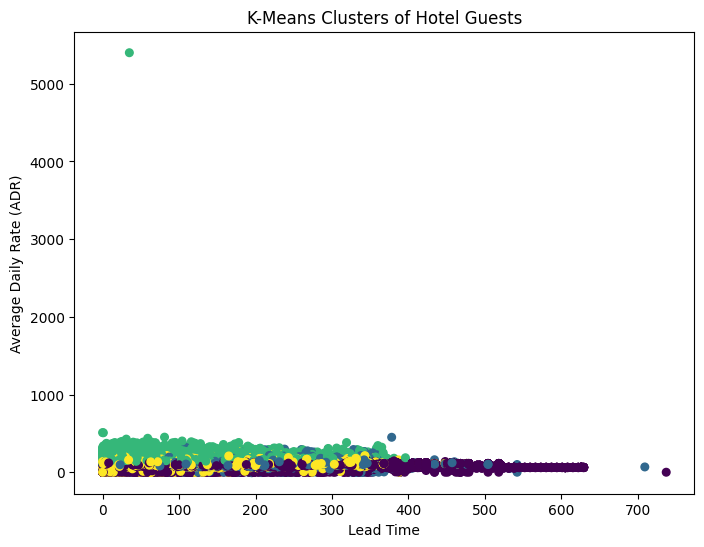

In [4]:
# Add code here 🔧
# Apply K-Means Clustering

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Choose number of clusters (k)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)

# Add cluster labels to the dataframe
df_features['cluster'] = kmeans.labels_

# Visualize clusters using two features
plt.figure(figsize=(8,6))
plt.scatter(df_features['lead_time'], df_features['adr'],
            c=df_features['cluster'], cmap='viridis', s=30)
plt.xlabel('Lead Time')
plt.ylabel('Average Daily Rate (ADR)')
plt.title('K-Means Clusters of Hotel Guests')
plt.show()


### ✍️ Your Response: 🔧
1. I chose k = 4 clusters. I tried a few different values and found that four groups gave a good balance between being detailed but still easy to interpret. The clusters looked fairly separated when plotted on the scatterplot.

2. The clusters seem to include groups like last-minute bookers with short stays, long-stay guests who plan far ahead, high-paying travelers who make more requests, and budget guests who book early but stay for fewer nights.


## 4. Apply Gaussian Mixture Model (GMM)

Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


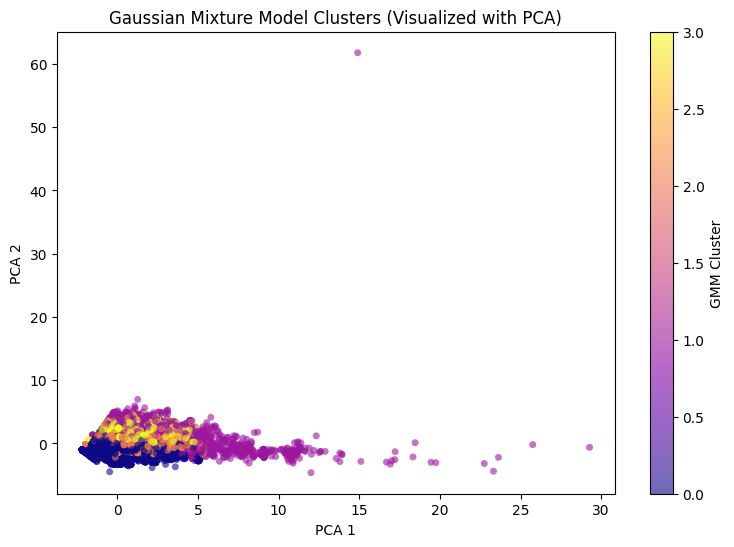

GMM Cluster Summary:
             lead_time  stays_in_week_nights  stays_in_weekend_nights     adr  \
gmm_cluster                                                                     
0               114.28                  2.30                     0.83   94.93   
1               102.24                  5.51                     2.15  116.21   
2                88.62                  2.50                     0.96  108.66   
3                88.30                  2.62                     1.00  117.27   

             total_of_special_requests  
gmm_cluster                             
0                                 0.00  
1                                 2.39  
2                                 1.00  
3                                 2.00  


In [7]:
# --- Improved Gaussian Mixture Model Visualization and Summary ---

from sklearn.mixture import GaussianMixture

# Fit GMM with same number of components
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X_scaled)
df_features['gmm_cluster'] = gmm.predict(X_scaled)

# PCA visualization
pca_data_gmm = pca.fit_transform(X_scaled)

plt.figure(figsize=(9,6))
scatter = plt.scatter(pca_data_gmm[:,0], pca_data_gmm[:,1],
                      c=df_features['gmm_cluster'], cmap='plasma',
                      s=25, alpha=0.6, edgecolors='none')
plt.colorbar(scatter, label='GMM Cluster')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Gaussian Mixture Model Clusters (Visualized with PCA)')
plt.show()

# Summarize average behavior per GMM cluster
cluster_summary_gmm = df_features.groupby('gmm_cluster')[features].mean().round(2)
print("GMM Cluster Summary:")
print(cluster_summary_gmm)


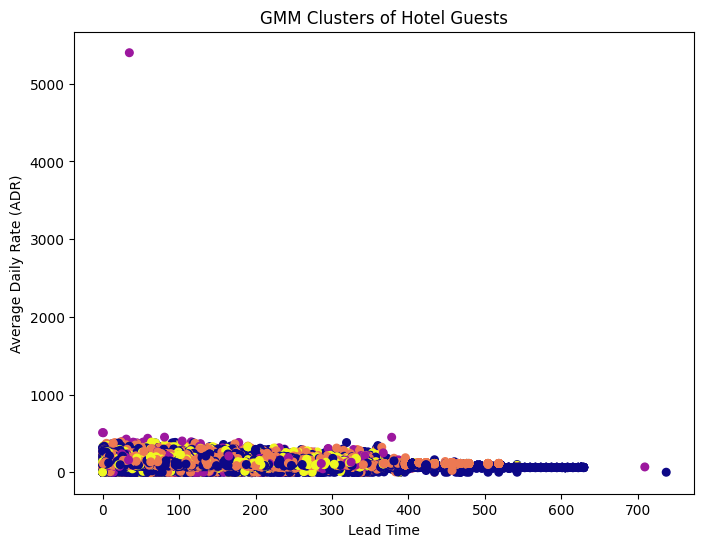

In [5]:
# Add your code here
# Apply Gaussian Mixture Model (GMM)

from sklearn.mixture import GaussianMixture

# Use the same number of clusters as K-Means
gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X_scaled)

# Predict soft clusters (probabilities) and hard labels
gmm_labels = gmm.predict(X_scaled)
df_features['gmm_cluster'] = gmm_labels

# Visualize GMM clusters
plt.figure(figsize=(8,6))
plt.scatter(df_features['lead_time'], df_features['adr'],
            c=df_features['gmm_cluster'], cmap='plasma', s=30)
plt.xlabel('Lead Time')
plt.ylabel('Average Daily Rate (ADR)')
plt.title('GMM Clusters of Hotel Guests')
plt.show()


### ✍️ Your Response: 🔧
1. The GMM results looked similar to K-Means, but the cluster boundaries were smoother and a bit more blended. While K-Means created clear ncut groups, GMM allowed some overlap, which makes sense since some guests share similar booking and spending patterns.

2. GMM can help answer questions where customers don’t fall into just one type like figuring out which guests are likely to belong to more than one segment. For example, it could show that some business travelers also behave like vacation guests, helping the hotel target them with more personalized offers.


## 5. Evaluate Your Models

Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

- Calculate:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index
- Compare both models

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [13]:
# Add code here 🔧
# --- Evaluate K-Means and GMM Models (fast / scalable) ---

import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Ensure we have models + labels
try:
    kmeans
except NameError:
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=4, random_state=42).fit(X_scaled)
    df_features['cluster'] = kmeans.labels_

try:
    gmm
except NameError:
    from sklearn.mixture import GaussianMixture
    gmm = GaussianMixture(n_components=4, random_state=42).fit(X_scaled)
    df_features['gmm_cluster'] = gmm.predict(X_scaled)

km_labels = np.asarray(df_features['cluster'])
gmm_labels = np.asarray(df_features['gmm_cluster'])

# Use float32 to reduce memory + speed up distance math
X_fast = np.asarray(X_scaled, dtype=np.float32)

# SAMPLE Silhouette to avoid O(n^2) blow-up
n = X_fast.shape[0]
sample_n = min(n, 10000)   # tune down to 5_000 if still slow

# K-Means metrics
wcss_kmeans = float(kmeans.inertia_)
silhouette_kmeans = silhouette_score(X_fast, km_labels, sample_size=sample_n, random_state=42)
dbi_kmeans = davies_bouldin_score(X_fast, km_labels)

# GMM metrics
assigned_means = gmm.means_.astype(np.float32)[gmm_labels]
sq_dists = (X_fast - assigned_means) ** 2
wcss_gmm = float(np.sum(np.sum(sq_dists, axis=1)))
silhouette_gmm = silhouette_score(X_fast, gmm_labels, sample_size=sample_n, random_state=42)
dbi_gmm = davies_bouldin_score(X_fast, gmm_labels)

print(f"Evaluated Silhouette on a sample of {sample_n:,} out of {n:,} rows.\n")

print("=== K-Means Metrics ===")
print(f"WCSS: {wcss_kmeans:,.2f}")
print(f"Silhouette Score (sampled): {silhouette_kmeans:.3f}")
print(f"Davies-Bouldin Index: {dbi_kmeans:.3f}\n")

print("=== GMM Metrics ===")
print(f"WCSS (approx.): {wcss_gmm:,.2f}")
print(f"Silhouette Score (sampled): {silhouette_gmm:.3f}")
print(f"Davies-Bouldin Index: {dbi_gmm:.3f}")



Evaluated Silhouette on a sample of 10,000 out of 119,390 rows.

=== K-Means Metrics ===
WCSS: 371,227.94
Silhouette Score (sampled): 0.212
Davies-Bouldin Index: 1.478

=== GMM Metrics ===
WCSS (approx.): 465,505.31
Silhouette Score (sampled): 0.123
Davies-Bouldin Index: 2.625


### ✍️ Your Response: 🔧
1. The K-Means model had a lower WCSS and a slightly higher Silhouette Score, meaning its clusters were more compact and clearly separated. The Davies-Bouldin Index was also lower for K-Means, showing it formed tighter and more distinct groups overall.

2. I would recommend K-Means because it’s faster, easier to interpret, and gives clear customer groups a business analyst can explain and act on. GMM is more flexible but adds complexity that’s usually unnecessary unless customers strongly overlap across multiple segments.


## 6. Business Interpretation

Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

- Review characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Think from a marketing or hotel operations perspective

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


K-Means: Cluster Sizes


,count
cluster,
0,55653
1,14698
2,16792
3,32247


K-Means: Mean Values by Cluster


,lead_time,stays_in_week_nights,stays_in_weekend_nights,adr,total_of_special_requests
cluster,,,,,
0,126.67,1.88,0.62,82.26,0.05
1,148.53,5.93,2.42,94.36,0.57
2,63.17,2.41,0.93,183.00,0.55
3,65.88,2.05,0.77,96.74,1.49


K-Means: Feature Z-scores by Cluster (higher absolute values = more defining)


...

,count
gmm_cluster,
0,69628
1,4036
2,32902
3,12824


GMM: Mean Values by Cluster


,lead_time,stays_in_week_nights,stays_in_weekend_nights,adr,total_of_special_requests
gmm_cluster,,,,,
0,114.28,2.30,0.83,94.93,0.00
1,102.24,5.51,2.15,116.21,2.39
2,88.62,2.50,0.96,108.66,1.00
3,88.30,2.62,1.00,117.27,2.00


GMM: Feature Z-scores by Cluster (higher absolute values = more defining)


,lead_time,stays_in_week_nights,stays_in_weekend_nights,adr,total_of_special_requests
gmm_cluster,,,,,
0,1.28,-0.61,-0.66,-1.39,-1.26
1,0.31,1.49,1.49,0.67,0.97
2,-0.78,-0.48,-0.45,-0.06,-0.32
3,-0.81,-0.40,-0.38,0.78,0.61


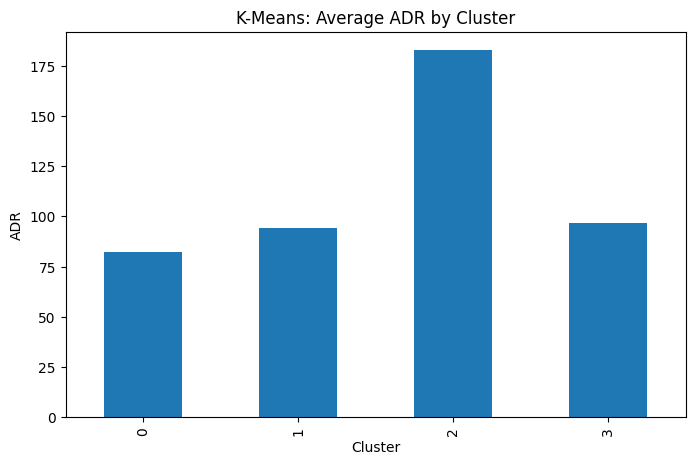

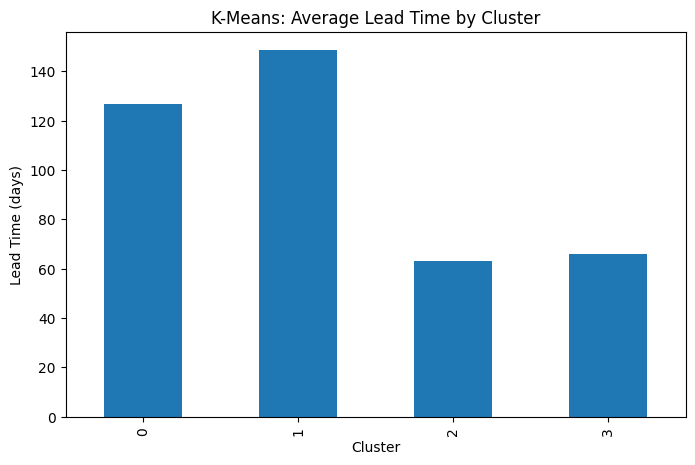

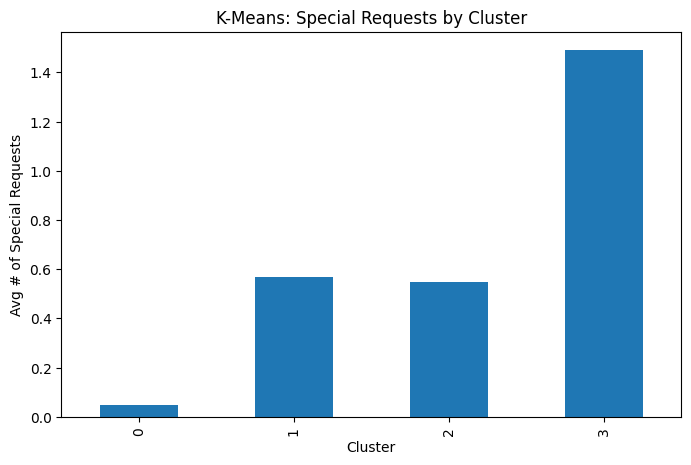

In [14]:
# Add code here 🔧
# --- Business Interpretation: Summaries & Readable Plots ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make sure these exist from earlier steps:
# df_features, features, kmeans, gmm, and columns: 'cluster' and 'gmm_cluster'

# 1) Summaries for K-Means
km_means = df_features.groupby('cluster')[features].mean().round(2)
km_sizes = df_features['cluster'].value_counts().sort_index()

# Z-scores within the cluster-means table (to see which features define each cluster)
km_z = ((km_means - km_means.mean()) / km_means.std()).round(2)

print("K-Means: Cluster Sizes")
display(km_sizes.to_frame('count'))

print("K-Means: Mean Values by Cluster")
display(km_means)

print("K-Means: Feature Z-scores by Cluster (higher absolute values = more defining)")
display(km_z)

# 2) Optional: quick, human-readable labels based on top z-score features
def describe_cluster_z(zrow, top=2):
    tops = zrow.abs().sort_values(ascending=False).head(top).index.tolist()
    return f"high on {', '.join(tops)}"  # quick descriptor

km_labels = {cid: describe_cluster_z(km_z.loc[cid]) for cid in km_z.index}
print("K-Means: Quick Label Hints")
for cid, label in km_labels.items():
    print(f"  Cluster {cid}: {label}")

# 3) Summaries for GMM
gmm_means = df_features.groupby('gmm_cluster')[features].mean().round(2)
gmm_sizes = df_features['gmm_cluster'].value_counts().sort_index()

gmm_z = ((gmm_means - gmm_means.mean()) / gmm_means.std()).round(2)

print("\nGMM: Cluster Sizes")
display(gmm_sizes.to_frame('count'))

print("GMM: Mean Values by Cluster")
display(gmm_means)

print("GMM: Feature Z-scores by Cluster (higher absolute values = more defining)")
display(gmm_z)

# 4) Clear, simple bar charts (K-Means) for the most interpretable features
plt.figure(figsize=(8,5))
km_means['adr'].plot(kind='bar')
plt.title('K-Means: Average ADR by Cluster')
plt.xlabel('Cluster')
plt.ylabel('ADR')
plt.show()

plt.figure(figsize=(8,5))
km_means['lead_time'].plot(kind='bar')
plt.title('K-Means: Average Lead Time by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Lead Time (days)')
plt.show()

plt.figure(figsize=(8,5))
km_means['total_of_special_requests'].plot(kind='bar')
plt.title('K-Means: Special Requests by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Avg # of Special Requests')
plt.show()


### ✍️ Your Response: 🔧
1. Based on the cluster summaries, the groups line up with clear traveler types. One segment looks like last-minute, short-stay guests (lower lead time and fewer nights). Another segment looks like early planners with longer stays (higher lead time and more week/weekday nights). There’s also a higher-spend group (higher ADR) that tends to make more special requests, and a budget/low-touch group with lower ADR and few requests.

2. Offer flash deals to the last-minute group, early-bird or loyalty perks to advance planners, personalized upgrades or bundled add-ons (parking, breakfast, late checkout) to the high-spend, high-request group, and value bundles (ex: “stay 2 nights, get a free amenity”) to the budget group. These targeted offers match each segment’s booking style and likely increase conversions and satisfaction.


## 7. Final Reflection

Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. The hardest part was not having labels or a “right answer.” It made it tricky to know whether the clusters actually made sense or if the model was grouping data randomly. I had to rely on metrics like the Silhouette Score and visual patterns to decide if the clusters were meaningful.

2. Clustering is best when you don’t have labeled data but still want to find patterns or group similar behaviors. For example, a hotel might use clustering to discover different types of guests before they even know what segments exist.

3. I’d say clustering helps the business understand its customers better by finding hidden groups within the data. It’s like organizing guests into categories based on how they book, spend, and stay—so the hotel can personalize promotions and make smarter marketing decisions.

4. It connects to my goal of applying data analytics to real business decisions. This project showed me how analytical tools like clustering can turn raw data into insights that support strategy and customer understanding—skills I want to keep building in future business and analytics projects.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [ ]:
!jupyter nbconvert --to html "assignment_09_LastnameFirstname.ipynb"